In [ ]:
import warnings

import numpy             as np
import pandas            as pd
import seaborn           as sns
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

PLOT_DPI = 220

def apply_large_plot_style():
    sns.set_theme(style="whitegrid", context="talk")
    plt.rcParams.update({
        "figure.dpi"      : PLOT_DPI,
        "savefig.dpi"     : PLOT_DPI,
        "font.size"       : 15,
        "axes.titlesize"  : 18,
        "axes.labelsize"  : 16,
        "xtick.labelsize" : 13,
        "ytick.labelsize" : 13,
        "legend.fontsize" : 12,
        "axes.titleweight": "bold",
    })

In [ ]:
def load_features(npz_path):
    data = np.load(npz_path, allow_pickle=True)
    
    return {key: data[key] for key in data.files}

In [ ]:
def compute_constraint(real_features, synth_features, features_to_check=None, 
                       percentile_low=1, percentile_high=99):

    if features_to_check is None:
        common_keys       = set(real_features.keys()) & set(synth_features.keys())
        features_to_check = []

        for k in sorted(common_keys):
            try:
                arr = np.asarray(real_features[k], dtype=float)
                
                if arr.ndim == 1 and len(arr) > 10 and np.issubdtype(arr.dtype, np.number):
                    features_to_check.append(k)
            except:
                continue
    
    results = []
    
    for feat in features_to_check:
        if feat not in real_features or feat not in synth_features:
            continue
            
        real_vals   = np.asarray(real_features[feat], dtype=float)
        synth_vals  = np.asarray(synth_features[feat], dtype=float)
        
        real_clean  = real_vals[~np.isnan(real_vals)]
        synth_clean = synth_vals[~np.isnan(synth_vals)]
        
        if len(real_clean) < 10 or len(synth_clean) < 10:
            continue
            
        lower      = np.nanpercentile(real_clean, percentile_low)
        upper      = np.nanpercentile(real_clean, percentile_high)
        synth_viol = np.mean((synth_clean < lower) | (synth_clean > upper)) * 100
        
        results.append({
            'Feature'          : feat,
            'Synth_Violation_%': round(synth_viol, 2),
            'Lower_Bound'      : round(lower, 4),
            'Upper_Bound'      : round(upper, 4),
            'n_real'           : len(real_clean),
            'n_synth'          : len(synth_clean)
        })
    
    violation_df = pd.DataFrame(results)

    if not violation_df.empty:
        violation_df = violation_df.sort_values('Synth_Violation_%', ascending=False).reset_index(drop=True)
    
    return violation_df

In [ ]:
def create_constraint_barplot(violation_df):
    apply_large_plot_style()
    
    if violation_df.empty:
        fig, ax = plt.subplots(figsize=(10, 6), dpi=PLOT_DPI)
        ax.text(0.5, 0.5, 'No constraint data available', ha='center', va='center', fontsize=18)
        ax.axis('off')
        return fig
    
    fig, ax = plt.subplots(figsize=(12, max(5, 0.55 * len(violation_df))), dpi=PLOT_DPI)
    
    sns.barplot(
        data      = violation_df, 
        y         = 'Feature', 
        x         = 'Synth_Violation_%',
        ax        = ax, 
        color     = '#FF9966',
        edgecolor = 'black', 
        linewidth = 0.7
    )
    
    ax.set_title(
        'Constraint Violation Rate in Synthetic Data',
        fontsize   = 18, 
        fontweight = 'bold', 
        pad        = 15
    )

    ax.set_xlabel('Violation Rate (%)', fontsize=16, labelpad=10)
    ax.set_ylabel('Feature', fontsize=16, labelpad=10)
    ax.tick_params(axis='both', labelsize=13)
    ax.grid(True, axis='x', alpha=0.3)
    
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f', padding=4, fontsize=11)
    
    plt.tight_layout()

    return fig

In [ ]:
def constraint_analysis(real_npz_path, synth_npz_path, features_to_check=None):
    real_features  = load_features(real_npz_path)
    synth_features = load_features(synth_npz_path)
    
    violation_df   = compute_constraint(real_features, 
                                        synth_features, 
                                        features_to_check = features_to_check)
    
    fig = create_constraint_barplot(violation_df)
    
    return violation_df, fig

## Run the Analysis

Loading features...
Real samples: 16 | Synth samples: 160
Computing synthetic constraint violations...
Creating visualization...


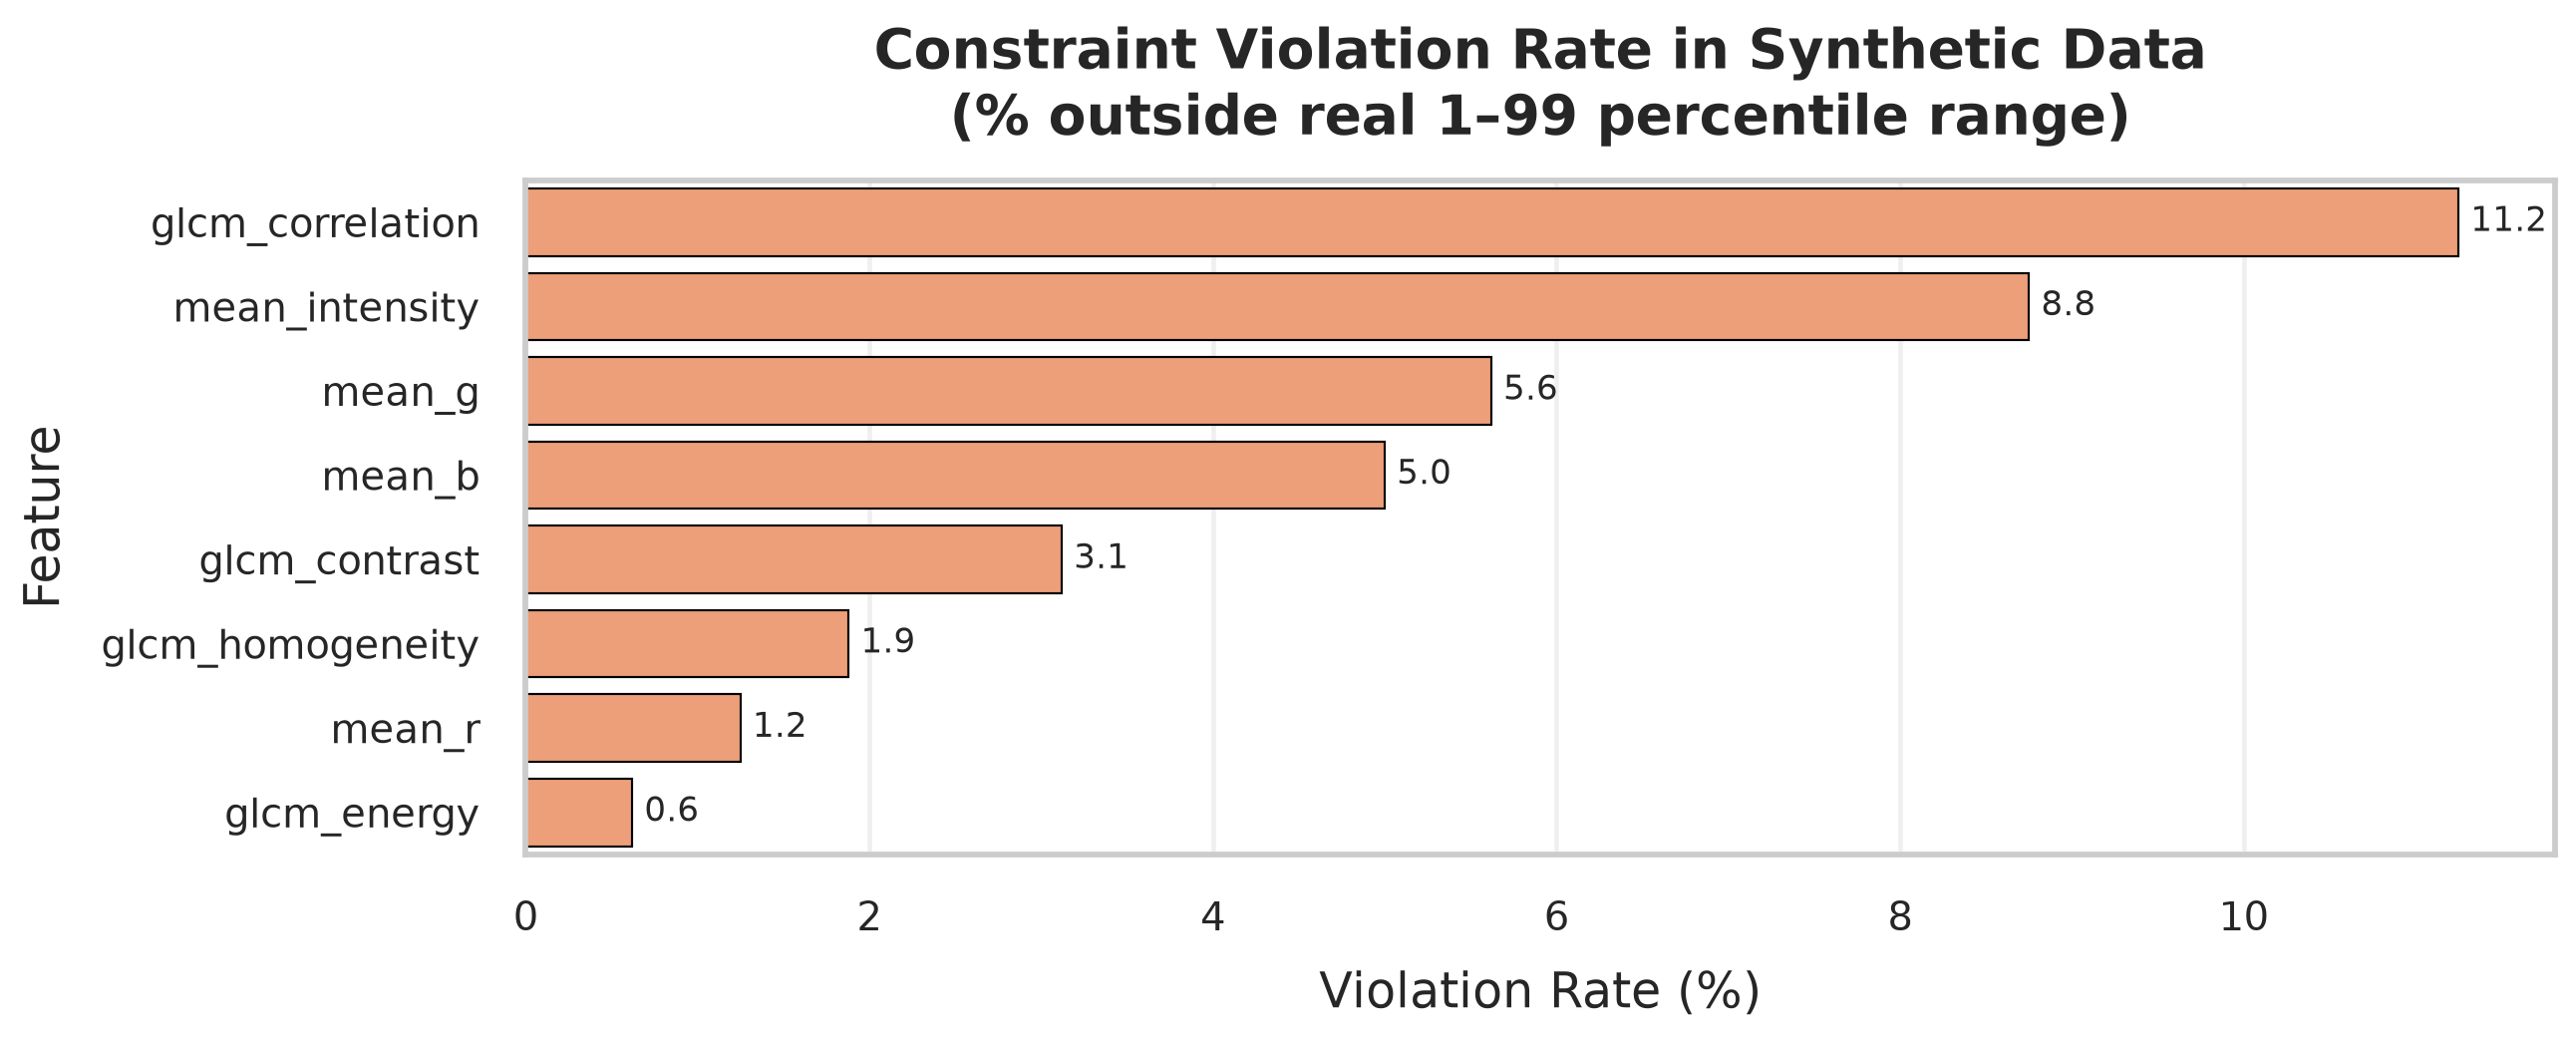

In [ ]:
REAL_NPZ                     = '../data/features/real_patch_appearance_features.npz'
SYNTH_NPZ                    = '../data/features/kde_patch_appearance_features.npz'

FEATURES_TO_CHECK            = None

violation_df, constraint_fig = constraint_analysis(REAL_NPZ, SYNTH_NPZ, 
                                                   features_to_check=FEATURES_TO_CHECK)